Feature Engineering means: Make smarter the data

Creating new useful features (columns) from existing data to help the model learn better.
Complete Machine Learning Workflow

This is how a real project looks.
Collect Data
      │
      ▼
Understand Data
      │
      ▼
EDA
      │
      ▼
Data Cleaning
      │
      ▼
Feature Engineering
      │
      ▼
Feature Selection
      │
      ▼
Split Train/Test
      │
      ▼
Scaling & Encoding
      │
      ▼
Build Model
      │
      ▼
Evaluate
      │
      ▼
Improve
      │
      ▼
Deploy

EDA: Understand data, Question like: How many missing values?

Any outliers?

Distribution?

Relationships?

Patterns?
EDA is like being a detective

Data Preprocessing: Fix data, Qustion like: Fill missing values

Encode text

Scale numbers

Remove duplicates

Prepare for ML

Data Preprocessing include: It includes much more:

Encoding
Scaling
Feature engineering
Pipelines
Transformations

## Lesson 2 — Data Cleaning (Industry-Level)

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(df)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30


In [2]:
df.head()

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22,IT,30000.0,2023-01-15
1,102,Sara,23,HR,35000.0,2022/05/10
2,103,john,Twenty Four,IT,NaN,15-08-2021
3,104,Mina,25,Finance,45000.0,2023-07-20
4,104,Mina,25,Finance,45000.0,2023-07-20


In [3]:
df.tail()

,Employee_ID,Name,Age,Department,Salary,Join_Date
3,104,Mina,25,Finance,45000.0,2023-07-20
4,104,Mina,25,Finance,45000.0,2023-07-20
5,106,NaN,-3,IT,-5000.0,Unknown
6,107,Alex,29,hr,52000.0,2024-01-05
7,108,EMMA,NaN,Finance,60000.0,2024-02-30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  8 non-null      int64  
 1   Name         7 non-null      str    
 2   Age          7 non-null      object 
 3   Department   8 non-null      str    
 4   Salary       7 non-null      float64
 5   Join_Date    8 non-null      str    
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 516.0+ bytes


In [5]:
df.describe(include="all")

,Employee_ID,Name,Age,Department,Salary,Join_Date
count,8.000000,7,7.0,8,7.000000,8
unique,NaN,6,6.0,4,NaN,7
top,NaN,Mina,25.0,IT,NaN,2023-07-20
freq,NaN,2,2.0,3,NaN,2
mean,104.375000,NaN,NaN,NaN,37428.571429,NaN
std,2.445842,NaN,NaN,NaN,21204.222401,NaN
min,101.000000,NaN,NaN,NaN,-5000.000000,NaN
25%,102.750000,NaN,NaN,NaN,32500.000000,NaN
50%,104.000000,NaN,NaN,NaN,45000.000000,NaN
75%,106.250000,NaN,NaN,NaN,48500.000000,NaN


In [6]:
df.describe()

,Employee_ID,Salary
count,8.000000,7.000000
mean,104.375000,37428.571429
std,2.445842,21204.222401
min,101.000000,-5000.000000
25%,102.750000,32500.000000
50%,104.000000,45000.000000
75%,106.250000,48500.000000
max,108.000000,60000.000000


In [7]:
df.isnull().sum()

Employee_ID    0
Name           1
Age            1
Department     0
Salary         1
Join_Date      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()] # find duplicates rows

,Employee_ID,Name,Age,Department,Salary,Join_Date
4,104,Mina,25,Finance,45000.0,2023-07-20


In [10]:
df = df.drop_duplicates() # remove duplicates and return new dataframe

In [11]:
df.dtypes

Employee_ID      int64
Name               str
Age             object
Department         str
Salary         float64
Join_Date          str
dtype: object

In [13]:
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
) # errors="coerce" will convert non-numeric values to NaN

In [14]:
df["Department"] = (
    df["Department"]
      .str.strip()
      .str.title()
)

In [15]:
df["Name"] = (
    df["Name"]
      .str.strip()
      .str.title()
)

In [16]:
df[df["Age"] < 0]

,Employee_ID,Name,Age,Department,Salary,Join_Date
5,106,NaN,-3.0,It,-5000.0,Unknown


In [17]:
df[df["Salary"] < 0]

,Employee_ID,Name,Age,Department,Salary,Join_Date
5,106,NaN,-3.0,It,-5000.0,Unknown


In [18]:
df.loc[df["Age"] < 0, "Age"] = np.nan

In [ ]:
df.loc[df["Age"] < 0, "Age"] = np.nan # .loc[row_condition, column_name] to update only the problematic cells.

In [ ]:
df["Join_Date"] = pd.to_datetime(
    df["Join_Date"],
    errors="coerce"
) # nvalid dates become NaT (Not a Time), which is the datetime equivalent of NaN.

In [21]:
df

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22.0,It,30000.0,2023-01-15
1,102,Sara,23.0,Hr,35000.0,NaT
2,103,John,NaN,It,NaN,NaT
3,104,Mina,25.0,Finance,45000.0,2023-07-20
5,106,NaN,NaN,It,-5000.0,NaT
6,107,Alex,29.0,Hr,52000.0,2024-01-05
7,108,Emma,NaN,Finance,60000.0,NaT


In [22]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Employee_ID  7 non-null      int64         
 1   Name         6 non-null      str           
 2   Age          4 non-null      float64       
 3   Department   7 non-null      str           
 4   Salary       6 non-null      float64       
 5   Join_Date    3 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 392.0 bytes
None
   Employee_ID  Name   Age Department   Salary  Join_Date
0          101  Abid  22.0         It  30000.0 2023-01-15
1          102  Sara  23.0         Hr  35000.0        NaT
2          103  John   NaN         It      NaN        NaT
3          104  Mina  25.0    Finance  45000.0 2023-07-20
5          106   NaN   NaN         It  -5000.0        NaT


In [23]:
df["Name"] = df["Name"].str.title()

In [24]:
df.isna().sum()

Employee_ID    0
Name           1
Age            3
Department     0
Salary         1
Join_Date      4
dtype: int64

In [27]:
"""
lesson.py

Mini Project:
Employee Data Inspection & Cleaning

Tasks:
1. Load the dataset
2. Inspect the dataset
3. Remove duplicate rows
4. Fix incorrect data types
5. Standardize text values
6. Handle impossible values
7. Convert date columns
8. Print before-and-after summaries

Author: Your Name
"""

# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(df)

# ==========================================================
# BEFORE CLEANING SUMMARY
# ==========================================================

print("=" * 50)
print("BEFORE CLEANING")
print("=" * 50)

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include="all"))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------
# Remove Duplicates
# ------------------------------------------

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

# ------------------------------------------
# Fix Data Types
# ------------------------------------------

df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

df["Salary"] = pd.to_numeric(
    df["Salary"],
    errors="coerce"
)

# ------------------------------------------
# Standardize Text
# ------------------------------------------

df["Name"] = (
    df["Name"]
    .str.strip()
    .str.title()
)

df["Department"] = (
    df["Department"]
    .str.strip()
    .str.upper()
)

df["Name"] = df["Name"].fillna("Unknown")

# ------------------------------------------
# Handle Impossible Values
# ------------------------------------------

df.loc[df["Age"] < 0, "Age"] = np.nan
df.loc[df["Salary"] < 0, "Salary"] = np.nan

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

# ------------------------------------------
# Convert Dates
# ------------------------------------------

df["Join_Date"] = pd.to_datetime(
    df["Join_Date"],
    errors="coerce",
    dayfirst=True
)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30
BEFORE CLEANING

First Five Rows
   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104 

C:\Users\HP\AppData\Local\Temp\ipykernel_2188\2285732506.py:170: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Join_Date"] = pd.to_datetime(


In [29]:
dfe = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(dfe)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30


In [34]:
dfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  8 non-null      int64  
 1   Name         7 non-null      str    
 2   Age          7 non-null      object 
 3   Department   8 non-null      str    
 4   Salary       7 non-null      float64
 5   Join_Date    8 non-null      str    
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 516.0+ bytes


In [31]:
print(dfe["Age"].unique())

[22 '23' 'Twenty Four' 25 -3 29 nan]


In [35]:
dfe["Age"] = dfe["Age"].replace({
    "Twenty Four": 24
})

In [37]:
# convert the "Age" column to numeric type, coercing errors to NaN
dfe["Age"] = dfe["Age"].replace("Twenty Four", 24)

dfe["Age"] = pd.to_numeric(
    dfe["Age"],
    errors="coerce"
)

In [38]:
dfe

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22.0,IT,30000.0,2023-01-15
1,102,Sara,23.0,HR,35000.0,2022/05/10
2,103,john,24.0,IT,NaN,15-08-2021
3,104,Mina,25.0,Finance,45000.0,2023-07-20
4,104,Mina,25.0,Finance,45000.0,2023-07-20
5,106,NaN,-3.0,IT,-5000.0,Unknown
6,107,Alex,29.0,hr,52000.0,2024-01-05
7,108,EMMA,NaN,Finance,60000.0,2024-02-30


## Lesson 3 — Missing Value Handling (Industry-Level Mastery)

In [39]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name":[
        "Abid","Sara","John","Mina",
        "David","Emma","Alex","Sophia"
    ],

    "Age":[
        22,21,np.nan,22,
        24,21,23,np.nan
    ],

    "Study_Hours":[
        10,15,8,np.nan,
        18,20,np.nan,16
    ],

    "Marks":[
        85,92,78,88,
        np.nan,97,72,90
    ],

    "Gender":[
        "Male","Female",
        np.nan,"Female",
        "Male","Female",
        "Male","Female"
    ]
})

print(df)

     Name   Age  Study_Hours  Marks  Gender
0    Abid  22.0         10.0   85.0    Male
1    Sara  21.0         15.0   92.0  Female
2    John   NaN          8.0   78.0     NaN
3    Mina  22.0          NaN   88.0  Female
4   David  24.0         18.0    NaN    Male
5    Emma  21.0         20.0   97.0  Female
6    Alex  23.0          NaN   72.0    Male
7  Sophia   NaN         16.0   90.0  Female


In [40]:
df.isnull().sum()

Name           0
Age            2
Study_Hours    2
Marks          1
Gender         1
dtype: int64

In [41]:
(df.isnull().mean()) * 100

Name            0.0
Age            25.0
Study_Hours    25.0
Marks          12.5
Gender         12.5
dtype: float64

In [42]:
df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

In [43]:
df["Marks"] = df["Marks"].fillna(
    df["Marks"].median()
)

When to Use Median? when using mean can be bias/make a huge difference

✅ Skewed data

Examples:

Salary
House prices
Income
Medical expenses
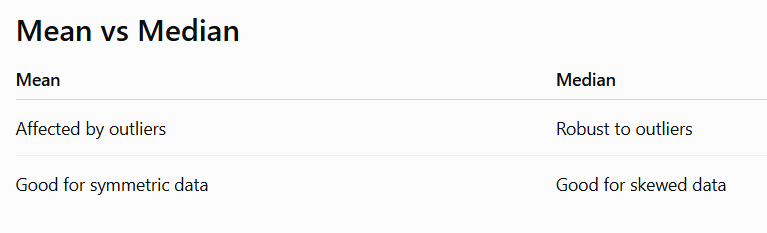

In [44]:
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

When to Use forward fill?

Time-series data:

Stock prices
Sensor readings
Weather data

Not usually appropriate for unrelated rows.

In [46]:
# df["Price"] = df["Price"].ffill()

In [47]:
# df["Price"] = df["Price"].bfill()

In [49]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name": ["Abid", "Sara", "John", "Mina", "David", "Emma"],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female"],
    "Salary": [50000, 60000, np.nan, 65000, 55000, np.nan]
})

print(df)

    Name  Gender   Salary
0   Abid    Male  50000.0
1   Sara  Female  60000.0
2   John    Male      NaN
3   Mina  Female  65000.0
4  David    Male  55000.0
5   Emma  Female      NaN


In [50]:
print(df.groupby("Gender")["Salary"].mean())

Gender
Female    62500.0
Male      52500.0
Name: Salary, dtype: float64


In [51]:
# Method 7 — Group-wise Imputation ⭐⭐⭐⭐⭐
# Calculate the mean within each gender.
df["Salary"] = df["Salary"].fillna(
    df.groupby("Gender")["Salary"].transform("mean")
)

In [52]:
df

,Name,Gender,Salary
0,Abid,Male,50000.0
1,Sara,Female,60000.0
2,John,Male,52500.0
3,Mina,Female,65000.0
4,David,Male,55000.0
5,Emma,Female,62500.0


Method 8 — KNN Imputation

Suppose one student's age is missing.

Find the most similar students using other features.

Use their ages to estimate the missing value.

This is the idea behind KNN Imputation.

In [57]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
df = pd.DataFrame({
    "Name": [
        "Abid",
        "Sara",
        "John",
        "Mina",
        "David",
        "Emma"],
    "Age": [
        22,
        23,
        np.nan,
        24,
        22,
        23],
    "Study_Hours": [
        10,
        15,
        11,
        np.nan,
        9,
        16],
    "Marks": [
        85,
        92,
        84,
        90,
        np.nan,
        95]})
print(df)

    Name   Age  Study_Hours  Marks
0   Abid  22.0         10.0   85.0
1   Sara  23.0         15.0   92.0
2   John   NaN         11.0   84.0
3   Mina  24.0          NaN   90.0
4  David  22.0          9.0    NaN
5   Emma  23.0         16.0   95.0


In [ ]:
imputer = KNNImputer(n_neighbors=3) # "For every missing value, look at the 3 most similar rows."

numeric_cols = ["Age", "Study_Hours", "Marks"]

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
# Avoid it for very large datasets because it can be computationally expensive.

In [61]:
df

,Name,Age,Study_Hours,Marks
0,Abid,22.000000,10.000000,85.000000
1,Sara,23.000000,15.000000,92.000000
2,John,22.666667,11.000000,84.000000
3,Mina,24.000000,13.333333,90.000000
4,David,22.000000,9.000000,86.333333
5,Emma,23.000000,16.000000,95.000000


## Method 9 — Iterative Imputation (MICE)
Idea:

Predict one missing feature using all the other features. it says "Let's train a machine learning model to predict each missing value using the other columns."

Repeat this process several times until the estimates stabilize.

This is one of the most advanced imputation methods.

Example:

Predict Age using:

Marks
Study Hours
Gender (after encoding)
Attendance

Then predict another feature using the updated data.

In [64]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Sample data
df = pd.DataFrame({
    "Age": [22, 23, np.nan, 24, 22, 23],
    "Study_Hours": [10, 15, 11, np.nan, 9, 16],
    "Marks": [85, 92, 84, 90, np.nan, 95]
})
print(df)

# Numeric columns
numeric_cols = ["Age", "Study_Hours", "Marks"]

# Create imputer
imputer = IterativeImputer(random_state=42)

# Impute missing values
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print(df)

    Age  Study_Hours  Marks
0  22.0         10.0   85.0
1  23.0         15.0   92.0
2   NaN         11.0   84.0
3  24.0          NaN   90.0
4  22.0          9.0    NaN
5  23.0         16.0   95.0
         Age  Study_Hours      Marks
0  22.000000    10.000000  85.000000
1  23.000000    15.000000  92.000000
2  22.483194    11.000000  84.000000
3  24.000000    17.084133  90.000000
4  22.000000     9.000000  81.925171
5  23.000000    16.000000  95.000000


In [65]:
# exercise
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Gender": ["Male", "Male", "Female", "Female", "Male", "Female"],
    "Salary": [50000, np.nan, 35000, np.nan, 55000, 40000]
})

print(df)
overall_mean = df["Salary"].mean()

print(overall_mean)
df["Salary"] = df["Salary"].fillna(overall_mean)

print(df)

   Gender   Salary
0    Male  50000.0
1    Male      NaN
2  Female  35000.0
3  Female      NaN
4    Male  55000.0
5  Female  40000.0
45000.0
   Gender   Salary
0    Male  50000.0
1    Male  45000.0
2  Female  35000.0
3  Female  45000.0
4    Male  55000.0
5  Female  40000.0


In [66]:
df = pd.DataFrame({
    "Gender": ["Male", "Male", "Female", "Female", "Male", "Female"],
    "Salary": [50000, np.nan, 35000, np.nan, 55000, 40000]
})
df["Salary"] = df["Salary"].fillna(
    df.groupby("Gender")["Salary"].transform("mean")
)

print(df)

   Gender   Salary
0    Male  50000.0
1    Male  52500.0
2  Female  35000.0
3  Female  37500.0
4    Male  55000.0
5  Female  40000.0


## Lesson 4 — Encoding Categorical Variables (Industry-Level Mastery)


## Label Encoding:
Advantages:  ✔ Very fast, ✔ Easy, ✔ Low memory

Disadvantages:  The model may think 2 > 1 > 0

which implies an order.

That is incorrect for nominal categories.
When Should We Use Label Encoding?

Good for: Binary categories

Example Male/Female, Yes/No, True/False

Also suitable for many tree-based models (Decision Trees, Random Forests, Gradient Boosting), because they don't interpret the numeric codes as distances.

Avoid using it for multi-class nominal variables with algorithms that rely on distances or linear relationships.

In [67]:
import pandas as pd

df = pd.DataFrame({

    "Gender":[
        "Male",
        "Female",
        "Female",
        "Male",
        "Female"
    ],

    "Department":[
        "IT",
        "HR",
        "Finance",
        "IT",
        "HR"
    ],

    "Education":[
        "Bachelor",
        "Master",
        "PhD",
        "Bachelor",
        "Secondary"
    ],

    "Salary":[
        50000,
        70000,
        90000,
        52000,
        45000
    ]

})

print(df)

   Gender Department  Education  Salary
0    Male         IT   Bachelor   50000
1  Female         HR     Master   70000
2  Female    Finance        PhD   90000
3    Male         IT   Bachelor   52000
4  Female         HR  Secondary   45000


In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [69]:
print(dict(zip(
    le.classes_,
    le.transform(le.classes_)
)))

{'Female': np.int64(0), 'Male': np.int64(1)}


## Method 2 — One-Hot Encoding ⭐⭐⭐⭐⭐
Advantages

✔ No false ordering

✔ Widely accepted

✔ Works with many algorithms
Disadvantages

If there are thousands of categories:

5000 Cities

↓

5000 columns

Memory usage increases dramatically.

In [70]:
pd.get_dummies(
    df,
    columns=["Department"]
)

,Gender,Education,Salary,Department_Finance,Department_HR,Department_IT
0,1,Bachelor,50000,False,False,True
1,0,Master,70000,False,True,False
2,0,PhD,90000,True,False,False
3,1,Bachelor,52000,False,False,True
4,0,Secondary,45000,False,True,False


In [ ]:
# Removes one dummy column.Useful for many linear models to avoid perfect multicollinearity (often called the "dummy variable trap").
pd.get_dummies(
    df,
    columns=["Department"],
    drop_first=True
)

,Gender,Education,Salary,Department_HR,Department_IT
0,1,Bachelor,50000,False,True
1,0,Master,70000,True,False
2,0,PhD,90000,False,False
3,1,Bachelor,52000,False,True
4,0,Secondary,45000,True,False


## Method 3 — Ordinal Encoding
Secondary → 0, Bachelor → 1, Master → 2, PhD → 3

In [74]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    categories=[
        [
            "Secondary",
            "Bachelor",
            "Master",
            "PhD"
        ]
    ]
)

df["Education"] = oe.fit_transform(
    df[["Education"]]
)

## Method 4 — Frequency Encoding
IT → 3

HR → 1

Finance → 1